In [15]:
import matplotlib.pyplot as plt
import numpy as np
import numpy as np
import matplotlib.pyplot as plt
import jax 
from jax import numpy as jnp
from flows.types import *
import optax
from flows.utils import *
from flows.models.linear import Linear
from flows.utils import *
import matplotlib.pyplot as plt
from functools import partial
from flows.Bases import Hermite 
from flows.bases import *
import flax.linen as nn
import sys 
import math
import pickle 
from flows.models.iresnet import InvertibleResNet
from flows.models.MLP import clip_kernel_svd_multiple
from scipy import constants
from sklearn.linear_model import LinearRegression

plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Computer Modern Roman'
fontsize_label = 18
fontsize_title = fontsize_label + 1
fontsize_legend = fontsize_label - 4
# size of the ticks 
plt.rcParams['xtick.labelsize'] = fontsize_label - 5
plt.rcParams['ytick.labelsize'] = fontsize_label - 5

print(f"available devices: {jax.devices()}")

available devices: [CpuDevice(id=0)]


In [16]:

def fit_power_law(N, losses2):
    N = np.asarray(N)
    losses2 = np.asarray(losses2)

    mask = (losses2 > 0) & (N > 0)
    N = N[mask]
    losses2 = losses2[mask]

    logN = np.log(N)
    logL = np.log(losses2)

    # linear fit: logL = -m logN + b
    A = np.vstack([logN, np.ones_like(logN)]).T
    slope, intercept = np.linalg.lstsq(A, logL, rcond=None)[0]

    m = -slope
    return m


def fit_stretched_exponential(N, losses1):
    N = np.asarray(N)
    losses1 = np.asarray(losses1)

    mask = (losses1 > 0) & (losses1 < 1) & (N > 0)
    N = N[mask]
    losses1 = losses1[mask]

    logN = np.log(N)
    Y = np.log(-np.log(losses1))

    # linear fit: Y = log(c) + delta logN
    A = np.vstack([logN, np.ones_like(logN)]).T
    delta, log_c = np.linalg.lstsq(A, Y, rcond=None)[0]

    c = np.exp(log_c)
    return c, delta

## Plot the convergence of Hermite approximations in various coordinates

Decay: algebraic, model: linear, power-law exponent: 2.64
Decay: algebraic, model: Hermite, power-law exponent: 1.67
Decay: algebraic, model: Sublinear, power-law exponent: 2.10
Decay: algebraic, model: iResNet, power-law exponent: 4.87
Decay: superGaussian, model: linear, stretched exponential exponent: 0.72, coefficient: 9.51e-01
Decay: superGaussian, model: Hermite, stretched exponential exponent: 0.47, coefficient: 1.06e+00
Decay: superGaussian, model: iResNet, stretched exponential exponent: 0.77, coefficient: 7.92e-01
Decay: superGaussian, model: subLin, stretched exponential exponent: 0.73, coefficient: 1.12e+00
Decay: superGaussian, model: subLin (asymp), stretched exponential exponent: 1.25, coefficient: 2.83e-01


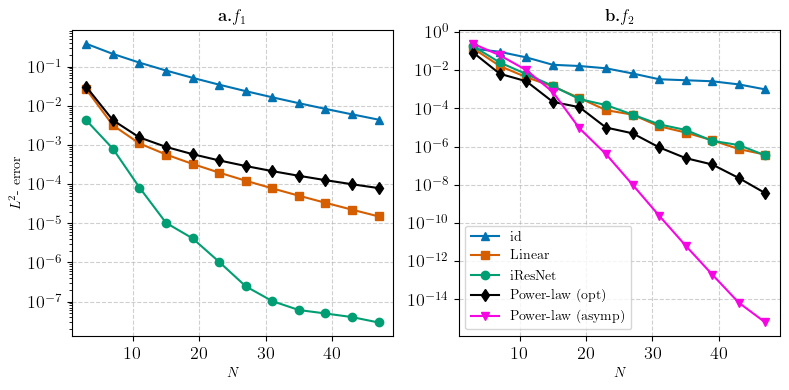

In [25]:
# load data from the simulations and plot the results
titles = [r"\bf{a.}$ f_1$", r"\bf{b.}$f_2$"]#, r"\bf{c.}$ f_3$"]
fig, axs = plt.subplots(1,2, figsize=(8,4), sharey=False)
for i, (decay, title) in enumerate(zip(["algebraic", "superGaussian",], titles)):
    if decay == "superGaussian":
        filename_sublin_asymp = f"simulations_data/losses_sublin_{decay}_manual.npz"
        data_sublin_asymp = np.load(filename_sublin_asymp)

        losses_sl_asymp = data_sublin_asymp["losses_nl"]

    data_Hermite = np.load(f"simulations_data/Hermite_{decay}.npz")
    size_basis = data_Hermite["size_basis"]
    losses_l = data_Hermite["losses_l"]

    data_lin = np.load(f"simulations_data/losses_lin_{decay}.npz")
    losses_lin = data_lin["losses_nl"]    
    
    filename_iResNet_10 = f"simulations_data/losses_iResNet_{decay}_lipswish_nlayers_10.npz"
    

    data_iResNet = np.load(filename_iResNet_10)
    losses_iResNet = data_iResNet["losses_nl"]

    filename_sublin = f"simulations_data/losses_sublin_{decay}.npz"
    data_sublin = np.load(filename_sublin)
    losses_sublin = data_sublin["losses_nl"]

    axs[i].plot(size_basis, losses_l, marker="^", color='#0173B2',
                 label="id")
    
    #='#029E73'
    axs[i].plot(size_basis, losses_lin, marker="s", color='#D55E00',
                label="Linear")
    
    axs[i].plot(size_basis, losses_iResNet, marker="o", color='#029E73', label="iResNet")

    axs[i].plot(size_basis, losses_sublin, marker="d", color="black", label="Power-law (opt)")
    if decay == "superGaussian":
        axs[i].plot(size_basis, losses_sl_asymp, marker="v", color="#F606E2", label="Power-law (asymp)")
    

    if decay == "algebraic":
        m_Hermite = fit_power_law(size_basis, losses_l)
        m_lin = fit_power_law(size_basis, losses_lin)
        m_sublin = fit_power_law(size_basis, losses_sublin)
        m_iResNet = fit_power_law(size_basis, losses_iResNet)
        print(f"Decay: {decay}, model: linear, power-law exponent: {m_lin:.2f}")
        print(f"Decay: {decay}, model: Hermite, power-law exponent: {m_Hermite:.2f}")
        print(f"Decay: {decay}, model: Sublinear, power-law exponent: {m_sublin:.2f}")
        print(f"Decay: {decay}, model: iResNet, power-law exponent: {m_iResNet:.2f}")
    else:
        c_Hermite, delta_Hermite = fit_stretched_exponential(size_basis, losses_l)
        c_lin, delta_lin = fit_stretched_exponential(size_basis, losses_lin)
        c_iResNet, delta_iResNet = fit_stretched_exponential(size_basis, losses_iResNet)

        c_sublin, delta_sublin = fit_stretched_exponential(size_basis, losses_sublin)
        c_sublin_asymp, delta_sublin_asymp = fit_stretched_exponential(size_basis, losses_sl_asymp)
        
        print(f"Decay: {decay}, model: linear, stretched exponential exponent: {delta_lin:.2f}, coefficient: {c_lin:.2e}")
        print(f"Decay: {decay}, model: Hermite, stretched exponential exponent: {delta_Hermite:.2f}, coefficient: {c_Hermite:.2e}")
        print(f"Decay: {decay}, model: iResNet, stretched exponential exponent: {delta_iResNet:.2f}, coefficient: {c_iResNet:.2e}")
        print(f"Decay: {decay}, model: subLin, stretched exponential exponent: {delta_sublin:.2f}, coefficient: {c_sublin:.2e}")
        print(f"Decay: {decay}, model: subLin (asymp), stretched exponential exponent: {delta_sublin_asymp:.2f}, coefficient: {c_sublin_asymp:.2e}")


    axs[i].set_title(title)
    axs[i].set_xlabel(r"$N$")

    axs[i].set_yscale("log")
    axs[i].grid(True, which='major', linestyle='--', alpha=0.6)

axs[0].set_ylabel(r"$L^2$- error")

axs[1].legend()

plt.tight_layout()

#plt.show()
plt.savefig("convergence_decay.pdf", bbox_inches="tight")

## Plot the loss functions for training

In [9]:
decay_list = ["algebraic", "superGaussian"]
for i, decay in enumerate(decay_list):
    print(f"decay: {decay}\n")
    filename_iResNet = f"simulations_data/iResNet_{decay}_lipswish_nlayers_10.npz"

    filename_sublin = f"simulations_data/sublin_{decay}.npz"

    filename_lin = f"simulations_data/lin_{decay}.npz"

    data_iResNet = np.load(filename_iResNet)
    n_epochs_iResNet = data_iResNet["epochs"]
    losses_nl_iResNet = data_iResNet["losses_nl"]
    
    sing_log_iResNet = data_iResNet["sing_loc"] if "sing_loc" in data_iResNet else None

    data_sublin = np.load(filename_sublin)
    losses_nl_sublin = data_sublin["losses_nl"]
    print(data_sublin)

    sing_log_sublin = data_sublin["sing_loc"] if "sing_loc" in data_sublin else None
    
    data_lin = np.load(filename_lin)
    n_epochs_lin = data_lin["epochs"]
    losses_nl_lin = data_lin["losses_nl"]
    sing_log_lin = data_lin["sing_loc"] if "sing_loc" in data_lin else None

    print(f"iResNet, last loss: {losses_nl_iResNet[-1]}")

    print(f"subLin, last loss: {losses_nl_sublin[-1]}")
    
    print(f"lin, last loss {losses_nl_lin[-1]}")
    if sing_log_iResNet is not None:
        print(f"resnet singularity location: {sing_log_iResNet}")
    print("\n")

    if sing_log_sublin is not None:
        print(f"sublin singularlity loc: {sing_log_sublin}")

    if sing_log_lin is not None:
        print(f"lin singularity loc: {sing_log_lin}")

decay: algebraic

NpzFile 'simulations_data/sublin_algebraic.npz' with keys: epochs, losses_nl, sing_loc
iResNet, last loss: 0.0012980125803429723
subLin, last loss: 0.030183729237890748
lin, last loss 0.027418907268564337
resnet singularity location: [2.69419903]


sublin singularlity loc: 1.5862299317459077e-14
lin singularity loc: [2.66890837]
decay: superGaussian

NpzFile 'simulations_data/sublin_superGaussian.npz' with keys: epochs, losses_nl
iResNet, last loss: 0.8133248481860461
subLin, last loss: 0.12658246373927418
lin, last loss 0.8312932268573208




In [11]:
for decay in ["algebraic", "superGaussian"]:
    filename = f"simulations_data/sublin_{decay}.pkl"
    with open(filename, "rb") as f:
        params = pickle.load(f)
        print(f"decay: {decay}, parameters: {params}")

decay: algebraic, parameters: {'params': {'scalar_power': Array(-0.36711375, dtype=float64), 'scalar_weight': Array(14.46134889, dtype=float64)}}
decay: superGaussian, parameters: {'params': {'scalar_power': Array(-0.35427419, dtype=float64), 'scalar_weight': Array(0.1419238, dtype=float64)}}


In [11]:
class MultipleResLin(nn.Module):
    number_of_layers: int
    dim: int
    activation: activationType=activationType.erf
    
    def setup(self):
        self.models = [InvertibleResNet([[8,8,self.dim]], lip=0.9, activation=self.activation,
                                        svd=svdType.direct) for _ in range(self.number_of_layers)]
        self.lin_model = Linear([1.]*self.dim, [0.]*self.dim)
    
    @nn.compact
    def __call__(self, x, mode=evaluationMode.direct):
        
        if mode == evaluationMode.direct:
            x = self.lin_model(x, mode=mode)
            for model_nl in self.models:
                x = model_nl(x, mode=mode)
            return x
        else:
            for model_nl in reversed(self.models):
            
                x = model_nl(x, mode=mode)
            x = self.lin_model(x, mode=mode)
            
            return x

class Lin(nn.Module):
    dim: int

    def setup(self):
        self.lin_model = Linear([1.], [0.])
 
    @nn.compact
    def __call__(self, x, mode=evaluationMode.direct):
        x = jnp.array(x)
        if mode == evaluationMode.direct:
            return self.lin_model(x)
        else:
            return self.lin_model(x, mode="inverse")


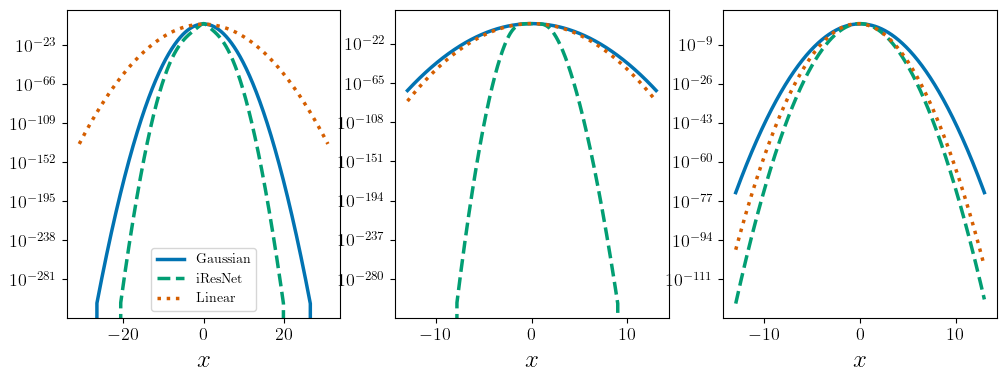

In [21]:
x_alg = jnp.linspace(-30.999, 30.999, 10000)[:, None]
x_rest = jnp.linspace(-12.999, 12.999, 10000)[:, None]

model_lin = Lin(1)
model_resnet = MultipleResLin(10, 1, activation=activationType.lipswish)

def Gaussian(x):
    return (jnp.exp(-x[:,0]**2))[:, None]

n_layers = 3 

figure, ax = plt.subplots(1, 3, figsize=(12,4))

for i, decay in enumerate(["algebraic", "superGaussian", "tanh"]):
    if decay == "algebraic":
        x = x_alg
    else:
        x = x_rest
    filename_iResNet = f"simulations_data/iResNet_{decay}_lipswish_nlayers_10.pkl" 
    if decay == "tanh":
        filename_lin = f"simulations_data/lin_{decay}_10.pkl"
    else:
        filename_lin = f"simulations_data/lin_{decay}.pkl"

    with open(filename_iResNet, "rb") as f:
        params = pickle.load(f)#['params']
    with open(filename_lin, "rb") as f:
        params_lin = pickle.load(f)#?['params']

        
    res_y_1 = model_resnet.apply(params, x, mode=evaluationMode.direct)
    res_deriv_1 = abs_det_jac_x(model_resnet, params, x, mode=evaluationMode.direct)

    lin_y = model_lin.apply(params_lin, x, mode=evaluationMode.direct)
    lin_deriv_ = abs_det_jac_x(model_lin, params_lin, x, mode=evaluationMode.direct)

    res_gaus_1 = Gaussian(res_y_1)[:,0]*res_deriv_1

    lin_gaus = Gaussian(lin_y)[:,0]*lin_deriv_

    ax[i].plot(x, Gaussian(x), label="Gaussian", color='#0173B2', linestyle="solid", linewidth=2.5)

    
    #len_gaus = Gaussian(lin_y)[:,0]*jnp.sqrt(lin_deriv_)
    ax[i].plot(x, res_gaus_1, color='#029E73',  label=r"iResNet", linestyle="--", linewidth=2.5)

    
    ax[i].plot(x, lin_gaus, color='#D55E00', label=r"Linear", linestyle=":", linewidth=2.5)

#ax.plot(x, len_gaus, color='#D55E00', label=r"Linear", linestyle=":", linewidth=2.5)
    ax[i].set_xlabel(r"$x$", fontsize=fontsize_label)
    ax[i].set_yscale("log")
ax[0].legend()
#plt.savefig("gaussian.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [57]:
filenames_sublin = [f"simulations_data/sublin_algebraic_10.pkl",
                    f"simulations_data/sublin_superGaussian_10.pkl",]
for filename_sublin in filenames_sublin:
    with open(filename_sublin, "rb") as f:
        sublin_params = pickle.load(f)#['params']

        print(sublin_params)


{'params': {'scalar_power': Array(0.49568143, dtype=float64), 'scalar_weight': Array(0.61245641, dtype=float64)}}
{'params': {'scalar_power': Array(-0.32817973, dtype=float64), 'scalar_weight': Array(1.63159767, dtype=float64)}}
